# Explore Autoregressive Methods on TiRex

In [1]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module
sys.path.append('../src') # Add the path to source modules

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch

from tirex import ForecastModel, load_model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [3]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series = len(data_test['series_index'].unique())
print(f"Number of time series in the test set: {number_series}")
data_test.head()

Number of time series in the test set: 361


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


# Load Model

In [4]:
model: ForecastModel = load_model("NX-AI/TiRex")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 35,291,200


# Problem definition

Selected time series HU_solar_generation_actual_15 with index 50 and shape (7172,)


<Axes: >

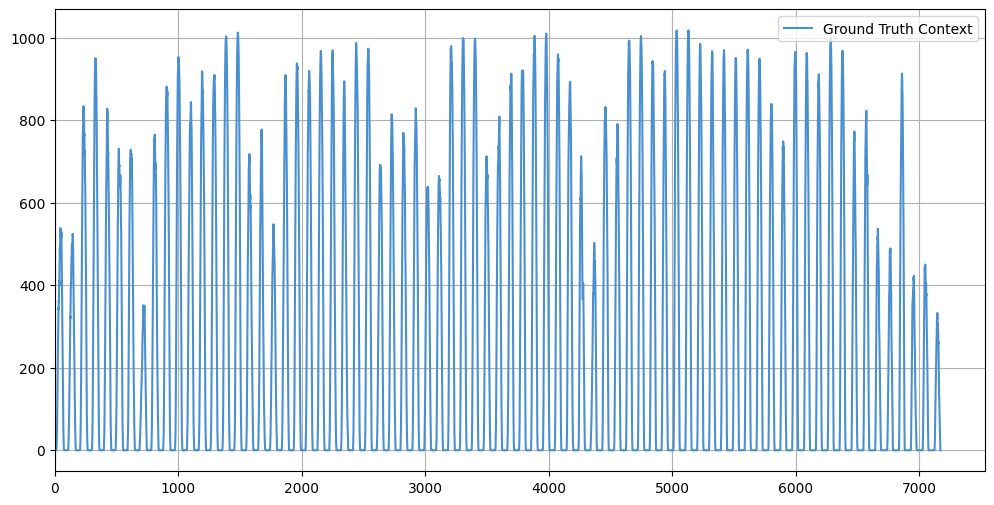

In [10]:
# select a single time series from the test data
idx_s = 50

df_s = data_test.filter(pl.col("series_index") == idx_s)
name_s = df_s.select(pl.col("series_name"))[0].item()
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1) # copy to make it writeable for the model
print(f"Selected time series {name_s} with index {idx_s} and shape {values_s.shape}")
plot_forecast(values_s)

In [ ]:
# set prediction length and starting point for prediction
prediction_length = 2200
start_point = 2048 # full context of the model is 2048

ctx_s, future_s = np.split(values_s, [start_point])
ctx_s.shape, future_s.shape

((2048,), (5124,))

In [16]:
quantiles, mean = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)

<Axes: >

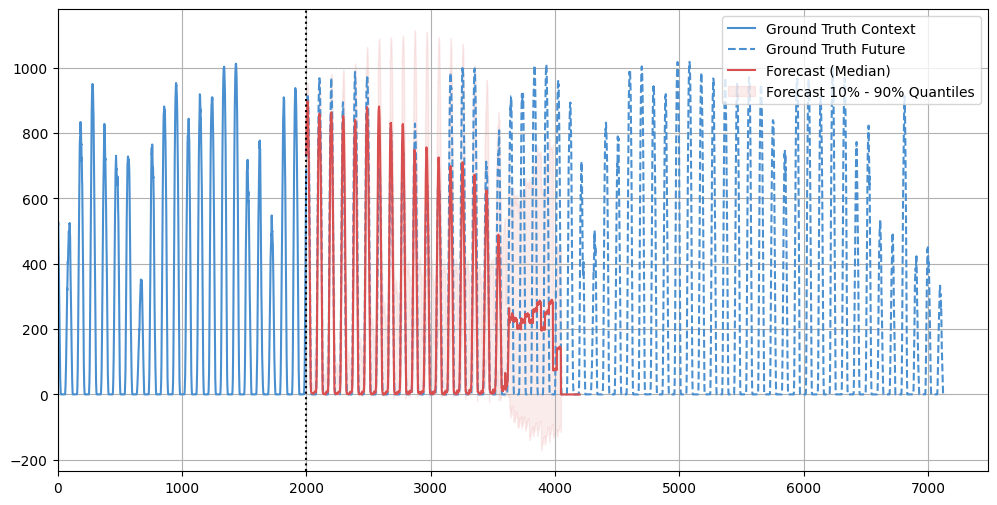

In [17]:
cap_input = -2000
plot_forecast(ctx_s[cap_input:], quantiles.numpy()[0], future_s)

On the plot we can see that Tirex failes for long term forecasts. After around forecast step 1600 it failes to predict and just outputs randomness until step 2048 which is the contect window of the trained model. There it just predicts zero. This is due to when Tirex predicts the next step it shifts the context and fill future values with null. So at step 2048 we have a full context of null values.

One solution to avoid this, would be to use the predicted value instead of null. So make the model autoregressive.

In [18]:
# TODO: implment MASE and MAPE for evaluation
# TODO: implement autoregressive forecasting loop to predict longer horizons than the model's context length